# `kruskal` — Kruskal MST 알고리즘 데모

[`algorithms/graph/kruskal.py`](kruskal.py) 는 textbook Kruskal MST — 간선을 가중치 오름차순으로 정렬한 뒤 Union-Find 로 사이클 여부를 판별해 `("add_edge", u, v, w)` / `("skip_edge", u, v, w)` 이벤트를 yield 한다.

[`algorithms/graph/trace.py`](trace.py) 의 `@trace` 데코레이터가 `kruskal.mst` helper 를 자동 부여한다. 무방향 그래프 전용이며 음수 가중치도 허용한다.

In [1]:
import sys

sys.path.insert(0, '../..')

import core.graph as g
from algorithms.graph.kruskal import kruskal

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')


def show(graph):
    """원본 그래프 위에 MST 간선을 강조."""
    return graph._to_graphviz(highlight=kruskal.mst(graph))

## 0. textbook 사용법

`kruskal(g)` — `("add_edge", u, v, w)` / `("skip_edge", u, v, w)` 이벤트 iterator. `kruskal.mst(g)` 로 MST `WeightedGraph` 를 바로 얻을 수 있다.

MST: WeightedGraph(undirected, V=5, E=4)


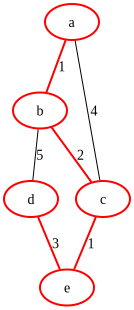

In [2]:
g0 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 1), (a, c, 4), (b, c, 2), (b, d, 5), (c, e, 1), (d, e, 3)]:
    g0.add_edge(u, v, w)

print('MST:', kruskal.mst(g0))
show(g0)

## 1. Path — `a -2- b -5- c -1- d`

이미 트리 구조 → 모든 간선이 MST 에 추가됨. `skip_edge` 없음.

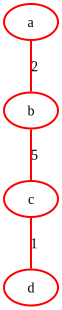

In [3]:
show(g.WeightedGraph(a - 2 - b - 5 - c - 1 - d))

## 2. Triangle — `a -1- b -2- c -3- a`

최저 가중치 간선 2개만 선택. 가장 무거운 `a-c(3)` 는 사이클을 만들어 skip.

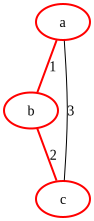

In [4]:
g2 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 1), (b, c, 2), (a, c, 3)]:
    g2.add_edge(u, v, w)

show(g2)

## 3. K4 — 완전 그래프 (가중치 있음)

```
a -3- b
a -1- c
a -7- d
b -2- c
b -1- d
c -5- d
```

MST: `a-c(1)`, `b-d(1)`, `b-c(2)`, 총 비용 4.

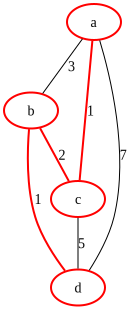

In [5]:
g3 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 3), (a, c, 1), (a, d, 7), (b, c, 2), (b, d, 1), (c, d, 5)]:
    g3.add_edge(u, v, w)

show(g3)

## 4. Dense — 6-node 복합 그래프

```
a -2- b -5- d
a -6- c     |
b -3- e -1- f
c -8- e
c -4- f
d -7- f
```

MST: `e-f(1)`, `a-b(2)`, `b-e(3)`, `c-f(4)`, `b-d(5)`, 총 비용 15.

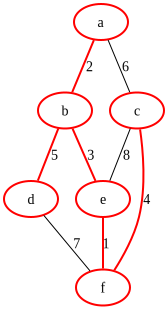

In [6]:
g4 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 2), (a, c, 6), (b, d, 5), (b, e, 3), (c, e, 8), (c, f, 4), (d, f, 7), (e, f, 1)]:
    g4.add_edge(u, v, w)

show(g4)

## 5. 비연결 그래프 → spanning forest

컴포넌트 1: `a -1- b -2- c`, 컴포넌트 2: `d -3- e`.

Kruskal 은 각 컴포넌트의 MST 를 독립적으로 구성 → spanning forest.

spanning forest: WeightedGraph(undirected, V=5, E=3)


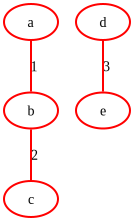

In [7]:
g5 = g.WeightedGraph[int]()
for u, v, w in [(a, b, 1), (b, c, 2), (d, e, 3)]:
    g5.add_edge(u, v, w)

print('spanning forest:', kruskal.mst(g5))
show(g5)

## 6. raw 이벤트 스트림

`kruskal(g)` 직접 소비 — `"add_edge"` / `"skip_edge"` 이벤트 출력. 가중치 오름차순으로 간선이 처리된다.

In [8]:
for event in kruskal(g0):
    match event:
        case ('add_edge', u, v, w):
            print(f'  add   {u} -{w}- {v}')
        case ('skip_edge', u, v, w):
            print(f'  skip  {u} -{w}- {v}  (cycle)')

  add   a -1- b
  add   c -1- e
  add   b -2- c
  add   d -3- e
  skip  a -4- c  (cycle)
  skip  b -5- d  (cycle)


---

## [Scenario] 5-City Telecom Network

통신사가 5개 도시를 최소 비용으로 연결하는 네트워크를 설계한다.

| Edge | Cities | Cost |
|------|--------|------|
| 0-1 | Seoul - Busan | 7 |
| 0-4 | Seoul - Daejeon | 1 |
| 1-2 | Busan - Daegu | 5 |
| 2-3 | Daegu - Gwangju | 8 |
| 2-4 | Daegu - Daejeon | 6 |
| 3-4 | Gwangju - Daejeon | 4 |
| 0-2 | Seoul - Daegu | 9 |
| 1-3 | Busan - Gwangju | 11 |

**(a)** MST 총 비용 계산  **(b)** `union(x, y)` 수도코드 (union by rank)  **(c)** path compression 의 amortized 시간 복잡도 효과

MST 간선:
  0 Seoul - 4 Daejeon: 1
  4 Daejeon - 3 Gwangju: 4
  1 Busan - 2 Daegu: 5
  4 Daejeon - 2 Daegu: 6
총 비용: 16


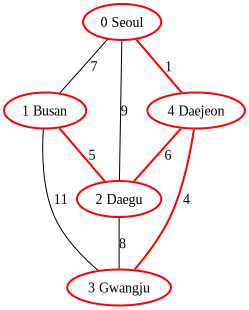

In [10]:
# (a) MST 총 비용
seoul, busan, daegu, gwangju, daejeon = g.vertices('0 Seoul', '1 Busan', '2 Daegu', '3 Gwangju', '4 Daejeon')

telecom = g.WeightedGraph[int]()
for u, v, w in [
    (seoul,   busan,   7),
    (seoul,   daejeon, 1),
    (busan,   daegu,   5),
    (daegu,   gwangju, 8),
    (daegu,   daejeon, 6),
    (gwangju, daejeon, 4),
    (seoul,   daegu,   9),
    (busan,   gwangju, 11),
]:
    telecom.add_edge(u, v, w)

mst = kruskal.mst(telecom)
total_cost = sum(w for _, _, w in mst.to_edge_list())

print('MST 간선:')
for u, v, w in sorted(mst.to_edge_list(), key=lambda e: e[2]):
    print(f'  {u} - {v}: {w}')
print(f'총 비용: {total_cost}')

telecom._to_graphviz(highlight=mst)

**(b) `union(x, y)` 수도코드 — union by rank**

```
function union(parent, rank, x, y):
    rx ← find(parent, x)
    ry ← find(parent, y)

    if rx == ry:
        return False          // 같은 컴포넌트 → 사이클

    if rank[rx] < rank[ry]:  // 더 얕은 트리를 깊은 트리 아래로
        swap(rx, ry)

    parent[ry] ← rx          // ry 를 rx 의 자식으로 연결

    if rank[rx] == rank[ry]: // 높이가 같을 때만 rank 증가
        rank[rx] ← rank[rx] + 1

    return True
```

Union by rank 는 항상 **높이가 낮은 트리를 높은 트리 아래에 붙인다**. 이로써 트리 높이가 O(log n) 을 초과하지 않는다.

**(c) Path compression 의 amortized 시간 복잡도 효과**

| 기법 | `find()` amortized |
|------|--------------------|
| 없음 | O(n) worst case |
| Union by rank 만 | O(log n) |
| Path compression 만 | O(log n) amortized |
| **Union by rank + Path compression** | **O(α(n)) ≈ O(1)** |

Path compression 은 `find(x)` 실행 중 경로 위의 **모든 노드를 직접 루트에 연결**한다. 이후 같은 노드에 대한 `find()` 는 O(1) 이 된다.

```
function find(parent, x):
    while parent[x] ≠ x:
        parent[x] ← parent[parent[x]]  // path halving (본 구현)
        x ← parent[x]
    return x
```

Union by rank 와 결합하면 트리가 이미 낮고, path compression 이 추가로 평탄화한다. n 번의 연산에 대한 전체 비용은 **O(n · α(n))** — α 는 역 아커만 함수로 n < 2^(2^(2^65536)) 범위에서 α(n) ≤ 4 이므로 실용적으로 **O(1)** 로 간주한다.